In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()

matplotlib.rcParams['font.family'] = "Arial"
matplotlib.rcParams['font.sans-serif'] = ["Arial"]


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8

['/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf']


In [2]:
import pandas as pd
data_water = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/water consumption.xlsx',index_col=0)
data_abandonment = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/abandonment_rate.xlsx',index_col=0).iloc[:, ::-1]


print(data_water)
print(data_abandonment)


weather_historical = pd.read_csv('/content/drive/MyDrive/NU work/Cotton/cotton_github/data/Weather/CMIP/historical/results_his_8f.csv')
weather_ssp1 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/cotton_github/data/Weather/CMIP/SSP1/results_SSP1_8f.csv')
weather_ssp2 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/cotton_github/data/Weather/CMIP/SSP2/results_SSP2_8f.csv')
weather_ssp3 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/cotton_github/data/Weather/CMIP/SSP3/results_SSP3_8f.csv')
weather_ssp5 =pd.read_csv('/content/drive/MyDrive/NU work/Cotton/cotton_github/data/Weather/CMIP/SSP5/results_SSP5_8f.csv')


                       2000         2001         2002         2003  \
Category                                                             
ALABAMA          184.629103   139.290695   220.848515   143.677625   
ARIZONA         6949.019553  8279.579533  6880.818862  7614.969065   
ARKANSAS        1535.154606  1401.521459  1391.988447  1333.022182   
CALIFORNIA      4840.446149  4855.432933  4501.038780  5036.342237   
FLORIDA          366.003456   281.048985   383.415558   292.369562   
GEORGIA          354.259620   306.045031   416.402448   305.102212   
KANSAS          3127.426830  2213.096063  1672.333089  1565.798717   
LOUISIANA        610.766913   698.114536   599.337574   432.379665   
MISSISSIPPI      585.111621   531.584494   480.989076   431.531746   
MISSOURI         761.098448   654.062877   732.062463   677.370922   
NEW MEXICO      6914.828012  5360.317667  5840.877468  5431.315738   
NORTH CAROLINA    20.872891    19.703725    40.952568    25.970287   
OKLAHOMA        1839

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# print(data_water, weather_historical.shape)

def process_weather_data(weather_historical, total_month, start=0, end=None):
  weather_historical = np.array(weather_historical).reshape(8, 17, total_month).reshape(8, 17, 12, total_month//12).transpose(1, 0, 2, 3).reshape(17, 96, total_month//12)[:,:,start:end]
  new_indices = [9, 15, 16, 8, 5, 10, 13, 4, 0, 11, 6, 1, 2, 14, 12, 7, 3]
  weather_historical_reordered = weather_historical[new_indices]
# Flatten the features
  features_flattened_train = weather_historical_reordered.transpose(0, 2, 1).reshape(-1, 96)
  return features_flattened_train

features_flattened_train = process_weather_data(weather_historical, 180)
features_flattened_test_ssp1 = process_weather_data(weather_ssp1, 420, end=9)
features_flattened_test_ssp2 = process_weather_data(weather_ssp2, 420, end=9)
features_flattened_test_ssp3 = process_weather_data(weather_ssp3, 420, end=9)
features_flattened_test_ssp5 = process_weather_data(weather_ssp5, 420, end=9)

features_flattened_predict_ssp1 = process_weather_data(weather_ssp1, 420, start=9)
features_flattened_predict_ssp2 = process_weather_data(weather_ssp2, 420, start=9)
features_flattened_predict_ssp3 = process_weather_data(weather_ssp3, 420, start=9)
features_flattened_predict_ssp5 = process_weather_data(weather_ssp5, 420, start=9)

print(features_flattened_train.shape)
print(features_flattened_test_ssp1.shape)


(255, 96)
(153, 96)


In [4]:
# Flatten the targets
water_targets_flattened_train = np.array(data_water)[:,:15].ravel()
water_targets_flattened_test = np.array(data_water)[:,15:].ravel()
print(water_targets_flattened_train.shape)
print(water_targets_flattened_test.shape)

abandonment_targets_flattened_train = np.array(data_abandonment)[:,:15].ravel()
abandonment_targets_flattened_test = np.array(data_abandonment)[:,15:].ravel()
print(abandonment_targets_flattened_train.shape)
print(abandonment_targets_flattened_test.shape)

(255,)
(153,)
(255,)
(153,)


In [5]:
import numpy as np
import pandas as pd
# from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor

X_train = features_flattened_train
y_train = water_targets_flattened_train

list_features_flattened_test = [features_flattened_test_ssp1,
                                features_flattened_test_ssp2,
                                features_flattened_test_ssp3,
                                features_flattened_test_ssp5]

y_test = water_targets_flattened_test



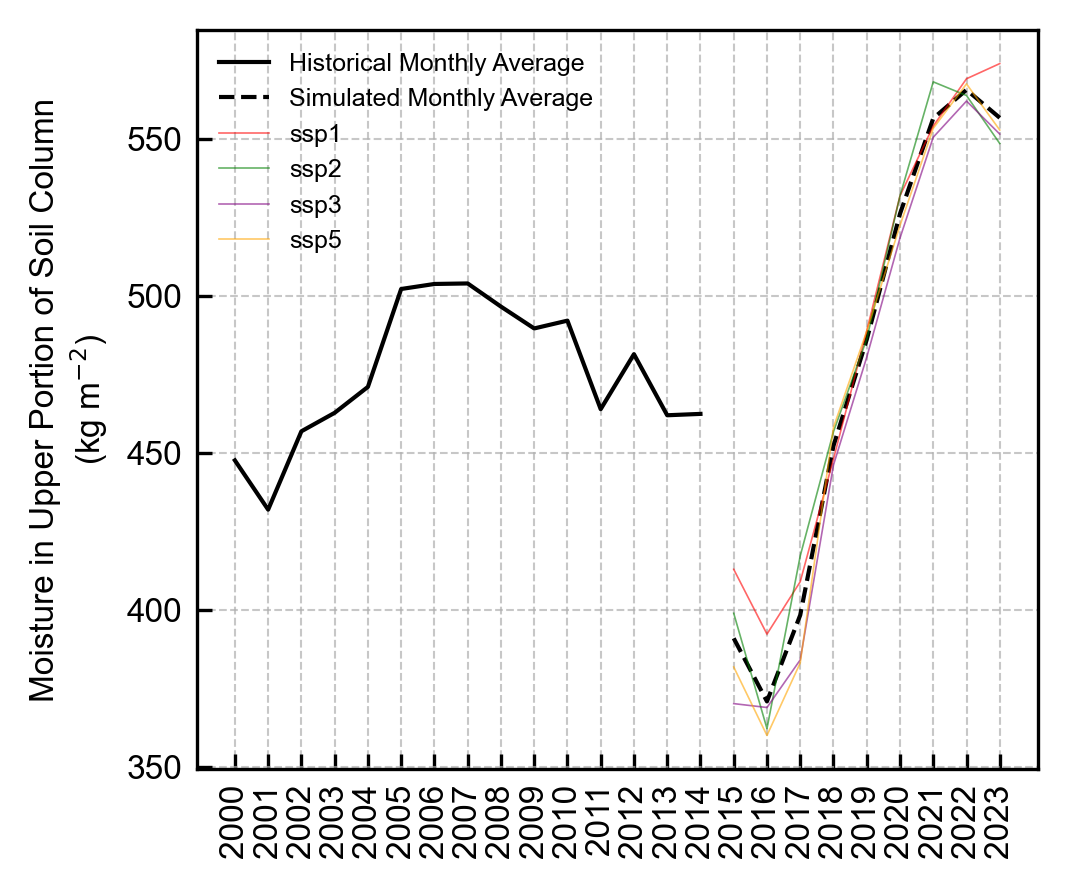

In [6]:
# exam the weather data
import seaborn as sns
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt

# Assuming features_flattened_train and other datasets are already defined

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'

# Create a figure with specified size
fig, ax = plt.subplots(figsize=(3.6, 3))  # Width and height in inches

# Plot the training data line
# train_line = (features_flattened_train[:, 5:6].reshape(17, 15).sum(axis=0) +
#               features_flattened_train[:, 6:7].reshape(17, 15).sum(axis=0) +
#               features_flattened_train[:, 7:8].reshape(17, 15).sum(axis=0))

train_line = features_flattened_train[:, 89:92].reshape(17, 15, 3).sum(axis=2).sum(axis=0)/3

ax.plot(range(0, 15), train_line, label='Historical Monthly Average', linestyle='-', color='black', linewidth=1)

# Define the range for the x-axis
x_range = range(15, 24)

# Calculate the sum of the specified slices for each dataset
# line1 = (features_flattened_test_ssp1[:, 32:33].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp1[:, 31:32].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp1[:, 34:35].reshape(17, 9).sum(axis=0))

# line2 = (features_flattened_test_ssp2[:, 32:33].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp2[:, 31:32].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp2[:, 34:35].reshape(17, 9).sum(axis=0))

# line3 = (features_flattened_test_ssp3[:, 32:33].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp3[:, 31:32].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp3[:, 34:35].reshape(17, 9).sum(axis=0))

# line4 = (features_flattened_test_ssp5[:, 32:33].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp5[:, 31:32].reshape(17, 9).sum(axis=0) +
#          features_flattened_test_ssp5[:, 34:35].reshape(17, 9).sum(axis=0))

line1 = features_flattened_test_ssp1[:, 89:92].reshape(17, 9, 3).sum(axis=2).sum(axis=0)/3
line2 = features_flattened_test_ssp2[:, 89:92].reshape(17, 9, 3).sum(axis=2).sum(axis=0)/3
line3 = features_flattened_test_ssp3[:, 89:92].reshape(17, 9, 3).sum(axis=2).sum(axis=0)/3
line4 = features_flattened_test_ssp5[:, 89:92].reshape(17, 9, 3).sum(axis=2).sum(axis=0)/3

# Stack the lines into a 2D array for averaging
lines_stack = np.vstack([line1, line2, line3, line4])

# Calculate the average across the stacked lines
average_line = np.mean(lines_stack, axis=0)

# Plot the average line
ax.plot(x_range, average_line, label='Simulated Monthly Average', linestyle='--', color='black', linewidth=1)

# Optionally, plot the individual lines for reference
ax.plot(x_range, line1, label='ssp1', linestyle='-', color='red', linewidth=0.4, alpha=0.6)
ax.plot(x_range, line2, label='ssp2', linestyle='-', color='green', linewidth=0.4, alpha=0.6)
ax.plot(x_range, line3, label='ssp3', linestyle='-', color='purple', linewidth=0.4, alpha=0.6)
ax.plot(x_range, line4, label='ssp5', linestyle='-', color='orange', linewidth=0.4, alpha=0.6)

# Combine the x-tick ranges from both plots
combined_x_range = list(range(0, 15)) + list(x_range)

# Set x-ticks to show all values
years = np.arange(2000, 2024)
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=90, ha='center')
ax.set_ylabel('Moisture in Upper Portion of Soil Column\n(kg m$^{-2}$)')
# Add labels and legend
# ax.set_xlabel('X-axis Label (units)', fontsize=12)
# ax.set_ylabel('Y-axis Label (units)', fontsize=12)
# ax.set_title('Average of Four Lines', fontsize=14, weight='bold')
ax.legend(fontsize=6, frameon=False)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust layout for better spacing
fig.tight_layout()

# Save the figure in high resolution
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/weather_figure.tif', dpi=300, bbox_inches='tight')
plt.show()



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# 1. Correlation Coefficients
def correlation_coefficients(X, y):
    corrs = []
    for i in range(X.shape[1]):
        corr, _ = pearsonr(X[:, i], y)
        corrs.append(corr)  # Take absolute value to focus on strength, not direction
    return np.array(corrs)

correlation_importances = correlation_coefficients(X_train, y_train)
print(correlation_importances)

# 2. Random Forest Feature Importance
rfc = RandomForestRegressor(n_estimators=1000, random_state=42)
rfc.fit(X_train, y_train)
rfc_importances = rfc.feature_importances_

# 3. Aggregate Feature Importance
# Normalize each method's importances to make them comparable
correlation_importances_abs = np.abs(correlation_importances) / np.sum(np.abs(correlation_importances))
rfc_importances = rfc_importances / np.sum(rfc_importances)

# Average the importances
overall_importance = np.mean([correlation_importances_abs, rfc_importances], axis=0)


# Months of the year
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Define feature categories
categories = ['pr', 'huss', 'mrro', 'sfcWind', 'tas', 'clt', 'evspsbl', 'mrsos']

# Generate feature names
features = [f'{category}_{month}' for category in categories for month in months]


importance_df = pd.DataFrame({'Feature': features, 'Correlation Importance': correlation_importances,
                              'RFC Importance': rfc_importances,
                              'Overall Importance': overall_importance})


print(importance_df)



[-0.50852991 -0.46113086 -0.44825187 -0.28745109 -0.42561363 -0.45706924
 -0.48906014 -0.53217845 -0.42355708 -0.5246203  -0.53184952 -0.37503594
 -0.33150074 -0.37421008 -0.37523186 -0.24567088 -0.31257654 -0.37697729
 -0.35837292 -0.38554091 -0.32490675 -0.37431474 -0.36908929 -0.34124512
 -0.54501297 -0.50730032 -0.46928153 -0.2016507  -0.38211787 -0.50315843
 -0.55380242 -0.5429742  -0.50083105 -0.46554421 -0.50678428 -0.44359161
  0.04489422  0.06063691  0.06795298  0.04153197  0.01713112  0.13508619
  0.08447863  0.06434241  0.01947607  0.09480975  0.11280972  0.08706444
 -0.04675701 -0.09727701 -0.05466333 -0.06778368 -0.07764496 -0.08995634
 -0.08106208 -0.08367942 -0.07502822 -0.09995471 -0.06710309 -0.03820847
 -0.29599157 -0.28306935 -0.41139729 -0.1491219  -0.27603781 -0.24789164
 -0.31408538 -0.44061521 -0.38559434 -0.4174779  -0.39312686 -0.20777698
 -0.43893336 -0.42773072 -0.442226   -0.3363785  -0.38856719 -0.47355257
 -0.44709642 -0.43290227 -0.3915106  -0.44647066 -0

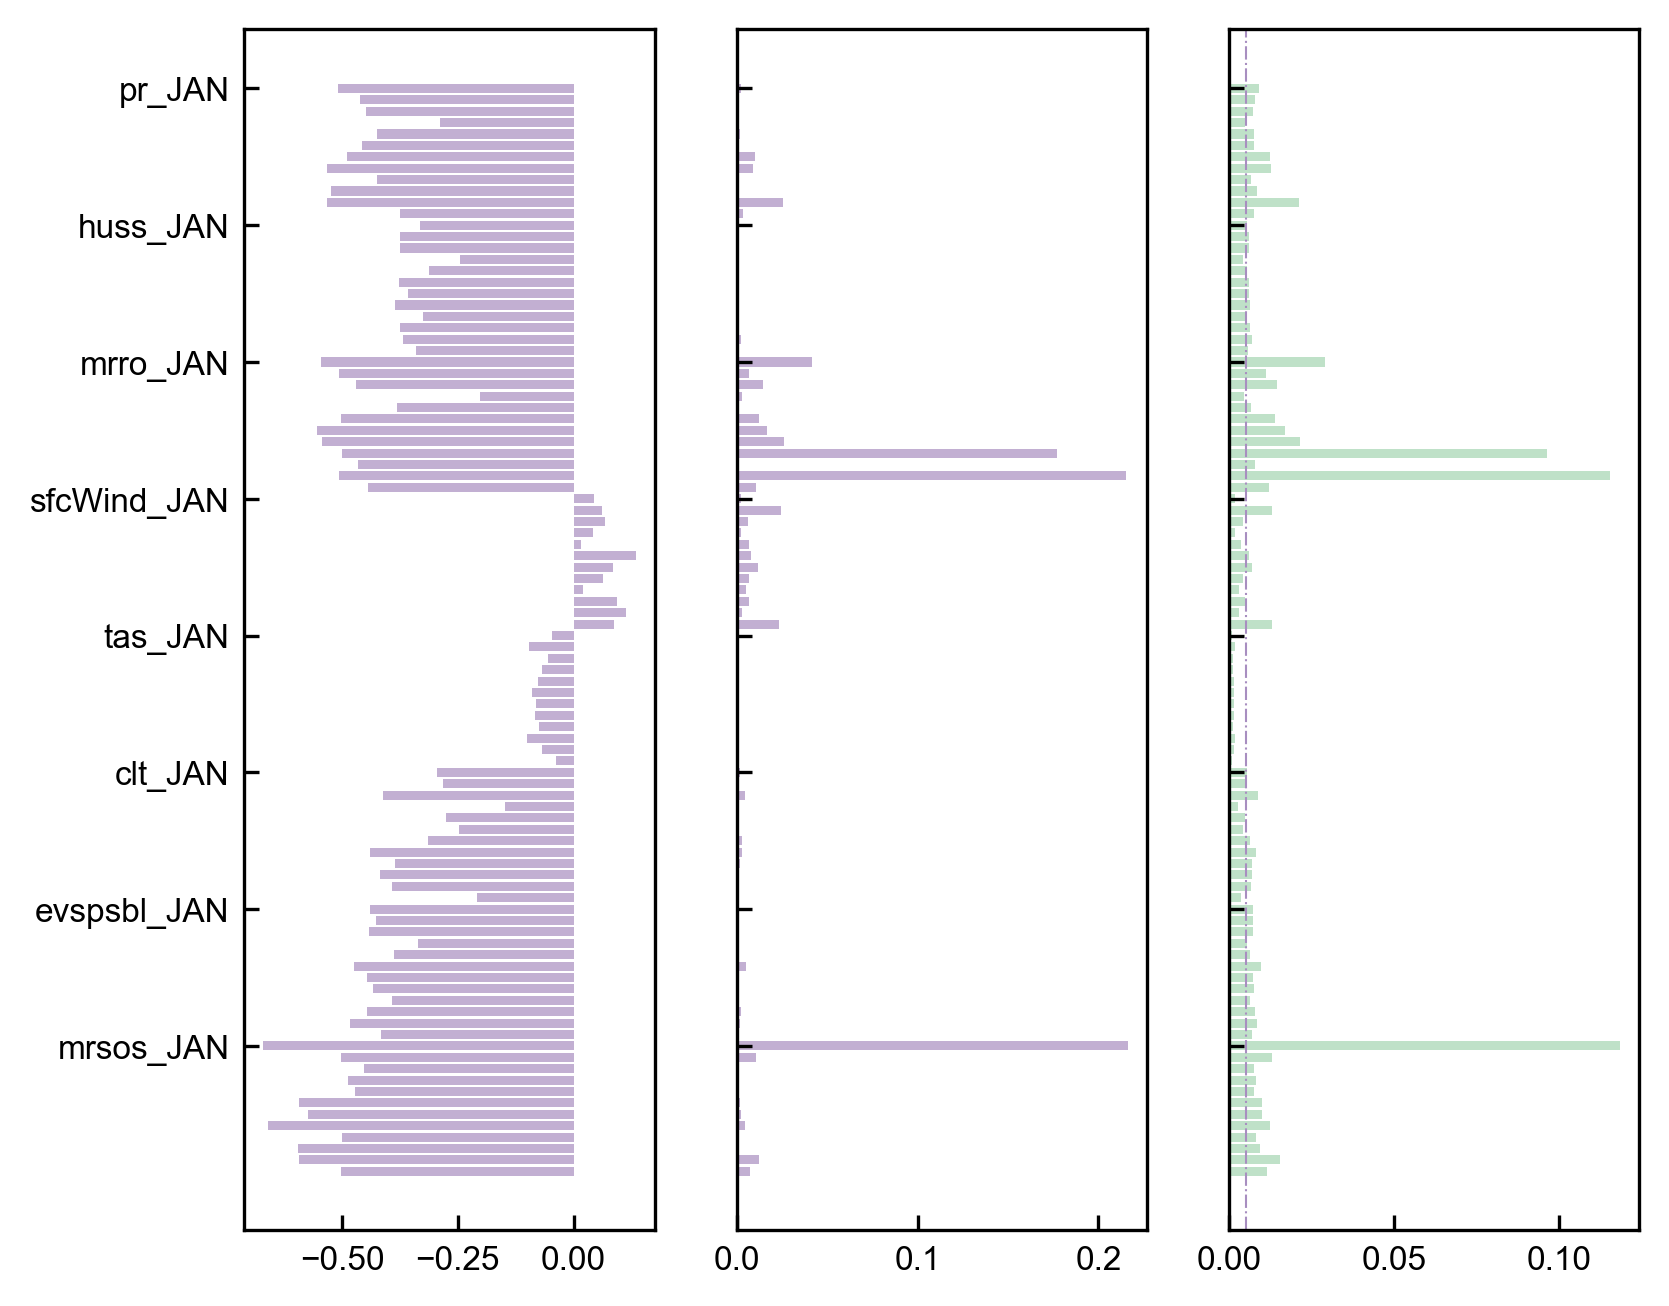

Selected 68 important features:
['pr_JAN' 'pr_FEB' 'pr_MAR' 'pr_MAY' 'pr_JUN' 'pr_JUL' 'pr_AUG' 'pr_SEP'
 'pr_OCT' 'pr_NOV' 'pr_DEC' 'huss_JAN' 'huss_FEB' 'huss_MAR' 'huss_MAY'
 'huss_JUN' 'huss_JUL' 'huss_AUG' 'huss_SEP' 'huss_OCT' 'huss_NOV'
 'huss_DEC' 'mrro_JAN' 'mrro_FEB' 'mrro_MAR' 'mrro_MAY' 'mrro_JUN'
 'mrro_JUL' 'mrro_AUG' 'mrro_SEP' 'mrro_OCT' 'mrro_NOV' 'mrro_DEC'
 'sfcWind_FEB' 'sfcWind_JUN' 'sfcWind_JUL' 'sfcWind_DEC' 'clt_JAN'
 'clt_MAR' 'clt_JUL' 'clt_AUG' 'clt_SEP' 'clt_OCT' 'clt_NOV' 'evspsbl_JAN'
 'evspsbl_FEB' 'evspsbl_MAR' 'evspsbl_APR' 'evspsbl_MAY' 'evspsbl_JUN'
 'evspsbl_JUL' 'evspsbl_AUG' 'evspsbl_SEP' 'evspsbl_OCT' 'evspsbl_NOV'
 'evspsbl_DEC' 'mrsos_JAN' 'mrsos_FEB' 'mrsos_MAR' 'mrsos_APR' 'mrsos_MAY'
 'mrsos_JUN' 'mrsos_JUL' 'mrsos_AUG' 'mrsos_SEP' 'mrsos_OCT' 'mrsos_NOV'
 'mrsos_DEC']


In [8]:
# plot the importance and define the threshold

# Plot the overall feature importances
fig, ax = plt.subplots(1, 3, figsize=(6, 5.2), sharey=True)
importance_threshold = 0.005
ax[2].barh(importance_df['Feature'], importance_df['Overall Importance'], color='#A4D5B1', alpha=0.7)
ax[0].barh(importance_df['Feature'], importance_df['Correlation Importance'], color='#A88EC0', alpha=0.7)
ax[1].barh(importance_df['Feature'], importance_df['RFC Importance'], color='#A88EC0', alpha=0.7)

# plt.xlabel('Importance')
# plt.ylabel('Features')
ax[2].axvline(x=importance_threshold, color='#A88EC0', linestyle='-.', linewidth=0.5)
# ax.text(0.025, ax.get_ylim()[1], 'Threshold: 0.005', color='k', ha='center', va='bottom',fontweight='bold' , fontsize=6, rotation=0)

yticks=importance_df['Feature']
ax[0].set_yticks(range(0, len(yticks), 12))
# ax.set_yticklabels(yticks[::6], fontsize=6, rotation=0)
# ax.set_yticklabels([])
# plt.title('Overall Feature Importances')
plt.gca().invert_yaxis()

plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_Fimportance.tiff',dpi=300, bbox_inches='tight')
plt.show()

# Define a threshold to select important features


# Select features above the threshold
important_features = importance_df[importance_df['Overall Importance'] > importance_threshold]['Feature'].values


print(f'Selected {len(important_features)} important features:')
print(important_features)

In [9]:
!pip install scikeras

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor

# Map the important feature names back to their indices
important_indices = [features.index(feature) for feature in important_features]


# Fixed Keras model with positive output constraint
def build_keras_mlp(input_dim):
    model = Sequential([
        Dense(50, input_dim=input_dim, activation='relu'),
        Dense(50, activation='relu'),
        Dense(1, activation='relu')
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Improved KerasRegressor with sklearn compatibility
class PositiveKerasRegressor(RegressorMixin,BaseEstimator):
    def __init__(self, input_dim, epochs=100, batch_size=32, verbose=0):
        self.input_dim = input_dim  # Changed from input_shape to input_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None

    def fit(self, X, y):
        self.model = build_keras_mlp(self.input_dim)
        self.model.fit(X, y,
                      epochs=self.epochs,
                      batch_size=self.batch_size,
                      verbose=self.verbose,
                      validation_split=0.1)  # Added validation split
        return self

    def predict(self, X):
        if self.model is None:
            raise RuntimeError("Model must be fitted before prediction")
        predictions = self.model.predict(X)
        return predictions.flatten()

# Calculate input dimension based on important features
input_dim = len(important_indices)  # Changed from shape[0] to use important_indices

# Corrected pipeline definitions using Pipeline instead of make_pipeline
mlp0 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

mlp1 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

mlp2 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

# mlp0 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('mlp', MLPRegressor( max_iter=1000, alpha=0.0001, hidden_layer_sizes=(50,50), learning_rate='constant', solver='adam'))
# ])

# mlp1 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('mlp', MLPRegressor( max_iter=1000, alpha=0.0001, hidden_layer_sizes=(50,50), learning_rate='constant', solver='adam'))
# ])

# mlp2 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('mlp', MLPRegressor( max_iter=1000, alpha=0.0001, hidden_layer_sizes=(50,50), learning_rate='constant', solver='adam'))
# ])




# 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate': 'constant', 'mlp__solver': 'adam'
# Create stacking regressor
meta_model = LinearRegression(fit_intercept=True)
base_models = [('mlp0', mlp0), ('mlp1', mlp1), ('mlp2', mlp2)]

stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=False,
    cv=5,
    n_jobs=-1  # Added parallel processing
)

# Train the model
stacking_regressor.fit(X_train[:, important_indices], y_train)




StackingRegressor(cv=5,
                  estimators=[('mlp0',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                PositiveKerasRegressor(input_dim=68))])),
                              ('mlp1',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                PositiveKerasRegressor(input_dim=68))])),
                              ('mlp2',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                PositiveKerasRegressor(input_dim=68))]))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [11]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define parameter grids for each model
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(50,), (50, 50)],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate': ['constant', 'adaptive']
}

param_grid_rf = {
    'n_estimators': [500],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2]
}

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto']
}

# Define MLP Pipeline
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=input_dim, epochs=100, batch_size=32, verbose=0))
])

# Define KNN Pipeline (with scaler)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Initialize models
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV objects
# gscv_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, cv=5, scoring='r2', n_jobs=-1)
gscv_mlp = mlp_pipeline
gscv_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
gscv_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='r2', n_jobs=-1)

# Fit models (assuming X_train, y_train, and important_indices are defined)
gscv_mlp.fit(X_train[:, important_indices], y_train)
gscv_rf.fit(X_train[:, important_indices], y_train)
gscv_knn.fit(X_train[:, important_indices], y_train)

models = [gscv_mlp, gscv_rf.best_estimator_, gscv_knn.best_estimator_]



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Scenario 1:
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

...

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/tmp/ipykernel_1049/1837141185.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[ 4.48701233e+02  4.77792297e+02  4.82946838e+02  4.52971008e+02
  6.36888794e+02  4.80902710e+02  4.80773010e+02  2.82750336e+02
  2.07437805e+02  6.93233643e+03  6.68210889e+03  6.81394336e+03
  7.62030371e+03  5.75158887e+03  6.00811572e+03  6.24377197e+03
  6.27264453e+03  6.03463916e+03  3.05844910e+02  2.21993164e+02
  4.61458984e+02  2.92072296e+02  3.37215332e+02  2.20715302e+02
  2.42170074e+02 -2.36181374e+01 -3.99838562e+01  4.26265039e+03
  4.32685303e+03  4.34328564e+03  4.49891455e+03  2.70097290e+03
  2.95899194e+03  3.07564185e+03  4.04485986e+03  3.87787256e+03
  3.17332458e+02  3.47375275e+02  4.25895508e+02  5.66669250e+02
  4.68746338e+02  3.96202667e+02  3.27594299e+02  4.99118958e+02
  4.50408173e+02  2.17197479e+02  3.86234863e+02  3.72132385e+02
  4.76105713e+02  5.53903748e+02  3.68018768e+02  3.48346161e+02
  2.58130127e+02  3.47854034e+02  2.10863647e+03  1.75665955e+03
  1.30801367e+03  1.84602917e+03  1.11370007e+03  1.

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/tmp/ipykernel_1049/1837141185.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


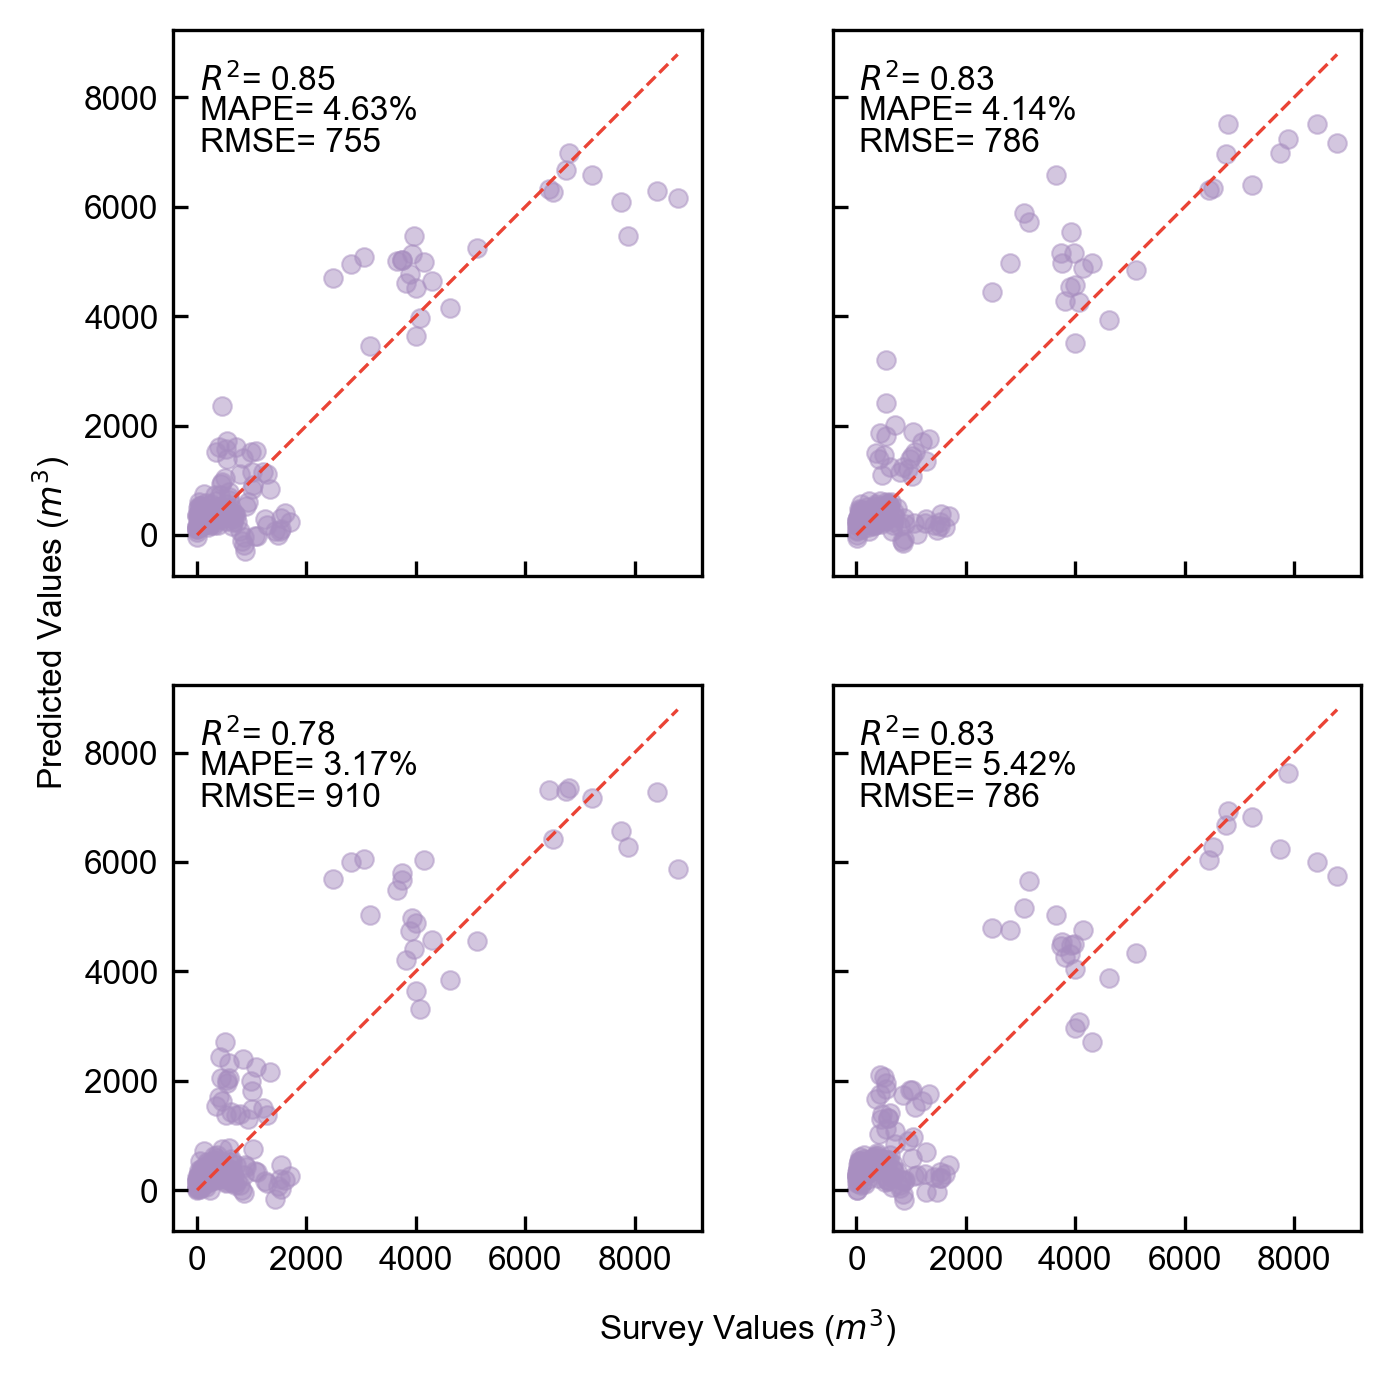

Scenario 1:
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[ 343.30713   391.51062   362.96188   411.9008    309.38882   111.15654
  378.56348   340.3198    297.99307  6366.5967   6017.6914   5953.935
 4942.1846   5751.915    5771.327    5593.099    5796.381    5953.498
  312.2305    269.94818   244.5043    252.45659   149.34447   204.47493
  251.42828   250.46483   163.94359  4252.1274   4438.3555   4820.9844
 5194.059    4240.2637   4347.1567   4032.2905   3465.8992   3849.904
  110.903206  228.23949   261.70425   365.82047   336.25198   156.8307
  372.33505   399.68158   232.55736   203.2413    330.49966   285.6675
  301.99423   275.14432   131.54558   323.10016   348.7324    283.46167
 1421.8892    924.4062   2054.9783   1375.2395   1618.1646   1629.2659
 1829.0593   1418.9043   1542.2542    365.89737   263.5263    269.2664
  467.82745   360.1155    259.71005   451.83594   437.99033   332.2521
  415.7285    378.29752   377.5742    469.50375   339.4841    239.95412
  453.73712   400.16367   

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword arg

[ 372.09857   204.46461   316.35233   261.4305    242.3643    207.0538
   90.36649   163.22922   161.24577  6826.0796   6671.9375   6279.0605
 5974.9033   5727.5015   6836.257    5998.331    5936.1846   6821.648
  238.98434   237.27234   193.73848   183.02371   198.94807   211.54613
  116.35454   614.45575   142.84009  3784.0903   4191.718    4216.6455
 4064.0125   4268.7505   4586.3735   3243.4827   3534.7793   3411.0364
  239.66171   203.70819   276.6837    383.4116    418.0243    222.81163
  217.40291   285.5757    238.17354   288.3519    179.4806    256.86194
  200.27872   238.25089   149.18631    61.067677  149.0034    136.08546
 2397.1567   2292.5073   1409.6605   1636.7179   1831.1299   1539.6367
 1805.3389   2868.6494   1857.174     299.03104   195.916     294.70795
  418.60925   348.17737   373.77945   161.84843   220.5893    313.57327
  378.4404    202.35963   360.87006   370.95462   346.93063   330.98184
  152.8504    213.45961   270.5303    572.8247    304.5659    256.7633


/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


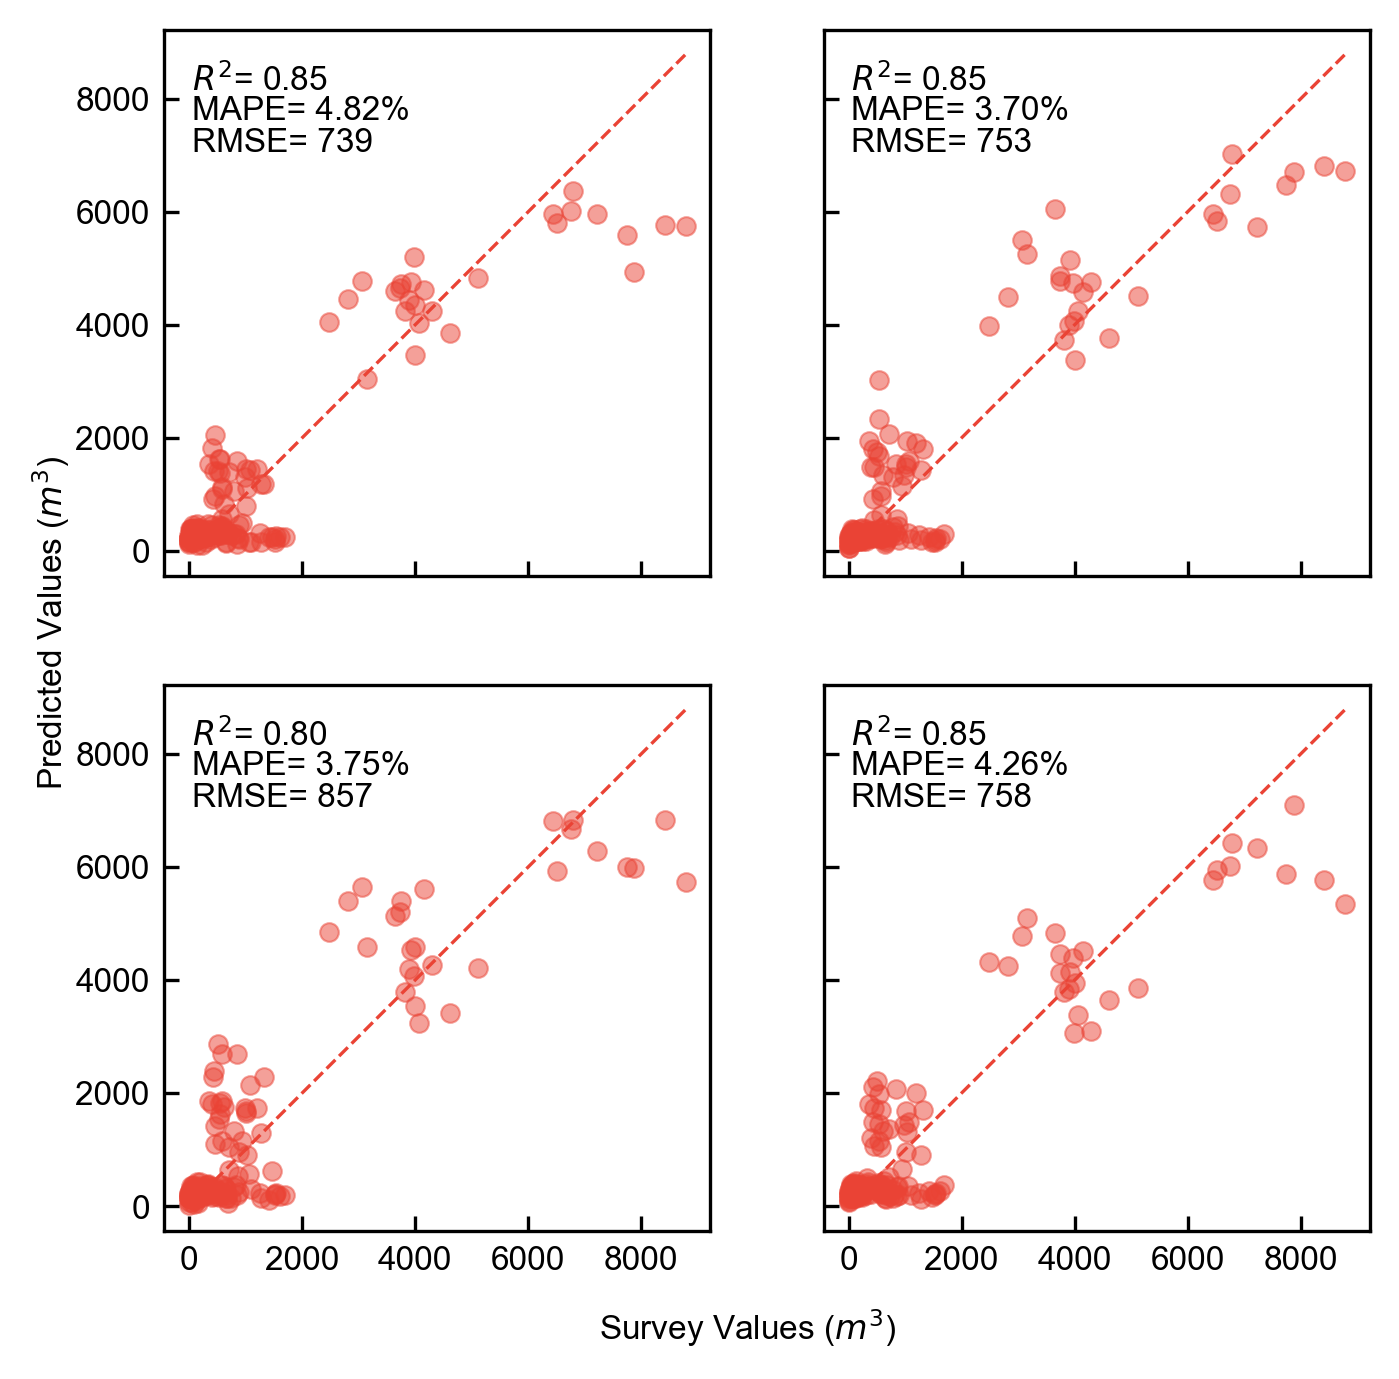

Scenario 1:
[ 295.55678957  254.98197484  235.77362711  311.81395978  207.67517349
  240.69711632  306.6547995   287.3118814   242.8772207  4968.49068952
 5060.93549769 4957.21559905 4488.11528399 4805.58344261 4565.20039265
 3935.26499357 5375.41624722 5415.11919388  823.08184303  911.53269427
  822.09518593  522.17940676  950.93682996  815.76643437  895.14569011
  691.75812308  979.12912472 1945.40514222 2757.72850883 4304.09131092
 4667.11143726 4718.09710242 4960.27876695 5011.03554291 5200.22711793
 3559.21424055 2025.97637823 2350.65174936 2661.22798408  903.5846359
 1108.62992886 2877.78301748  810.78582562  470.8958926   863.89383633
  311.8360332   260.82659503  287.67326696  281.11145269  239.01662301
  222.98046991  251.42742377  242.85219095  212.25242668 2590.71169971
 1801.66909053 3062.07273589 2472.61208986 2849.83086418 3289.33951428
 3241.18756847 3838.2874673  3874.0732202   700.03080357  646.65503463
  641.19177647  517.0983725   668.15463538  613.31101318  653.9185

/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


[ 317.7257492   290.69955608  694.66063326  219.35431588  238.838056
  151.45481421  239.52312147  281.39168391  324.62197615 5657.91760795
 5065.61611218 4836.34888609 5363.10901748 6279.39280791 6798.70627692
 6050.26121356 5664.55630703 6404.13975821 1379.90780066 1721.79210759
 1558.94351098  884.99674721  833.0474558  1215.28015818  621.19394311
 1278.85027623  781.36092782 2257.83132138 2290.0713401  2592.41462659
 4351.01063438 3835.42973879 3655.0005776  5366.40237557 3656.14238275
 3572.69902002  471.92993501  465.10753928  609.40126139  432.92502557
  473.13608532  806.16555881  414.23761603  691.20796684  602.95995587
  285.85867716  297.12248764  377.73323539  208.50663295  233.68023748
  150.05827396  234.24678883  230.69235857  215.7227623  2521.88238544
 2976.51397698 2776.54384976 2643.19274243 2993.87475403 3265.66619501
 3364.20090515 3953.76599658 2733.75817582  824.24522741  661.03596469
  796.48591296  665.55455482  725.02420936  747.29307678  661.71610598
  898.05

/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)


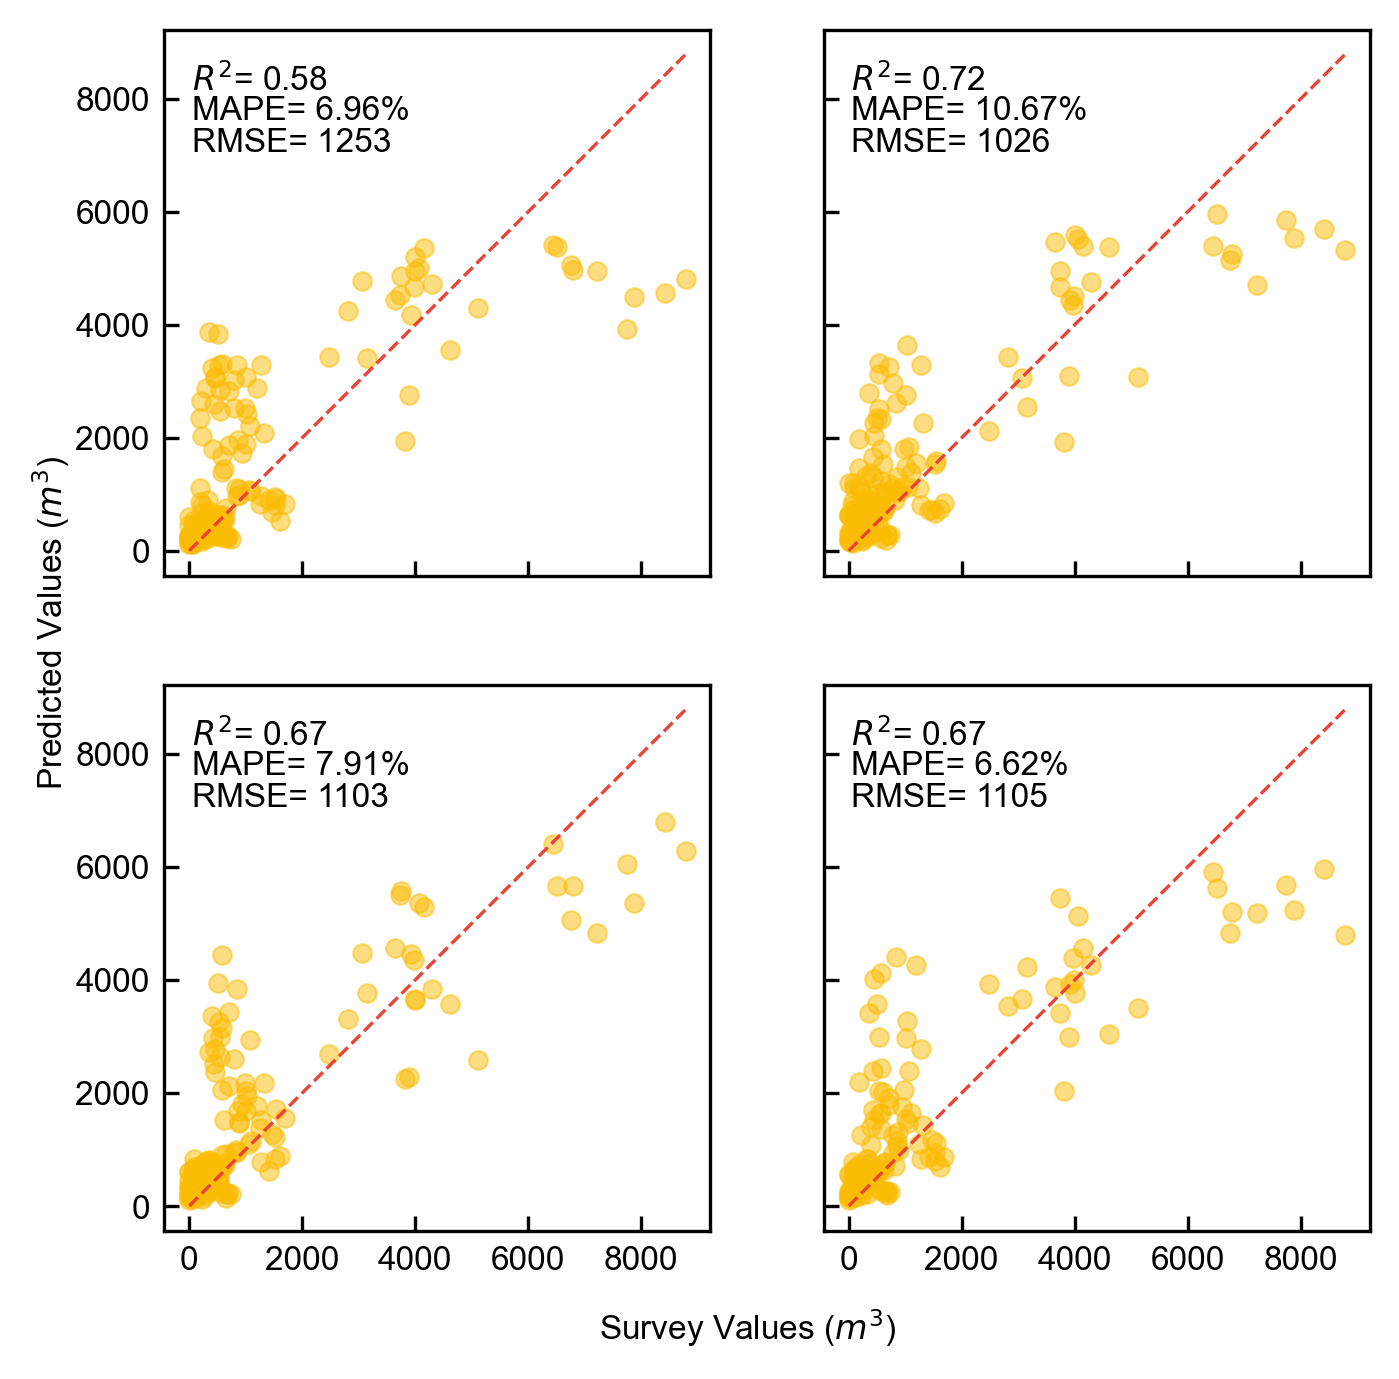

Scenario 1:
[ 305.78784812  434.14438259  308.1466849   466.28854153  442.4734228
  374.26473594  507.66836093  159.7678052   161.13659989 5327.21457265
 5285.09053375 5784.10954335 5333.7680856  6550.1395629  6439.35525241
 6862.17802762 6388.02612823 6791.43690391 1133.40068519  469.36966965
 1202.79313978  622.66627334  938.85274524  781.71524714 1242.94815396
  918.0798581   584.26204484 6188.04301671 6188.36781822 5413.57479926
 7114.91632898 6774.38403692 4225.53076263 5033.3825609  6956.57448742
 6963.58974154  243.4267694   273.33962943  243.36551535  245.66998026
  223.22922158  237.18815192  269.47143411  272.26175539  348.0599366
  371.05653214  425.96823802  363.11715135  318.73418545  414.14994317
  342.25496942  231.02595015  180.80928925  199.10453136 1566.72901269
 1443.71139243 1172.32414979 1340.88036828 1748.89980689 1763.26297534
 1648.70894905 1531.90466764 1102.86599736  375.59683668  289.88229103
  250.45229413  365.4682482   465.51335024  349.66796542  538.27532

/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
/tmp/ipykernel_1049/1837141185.py:82: UserWarning: color is redundantly defined by the 'color' keyword argument and th

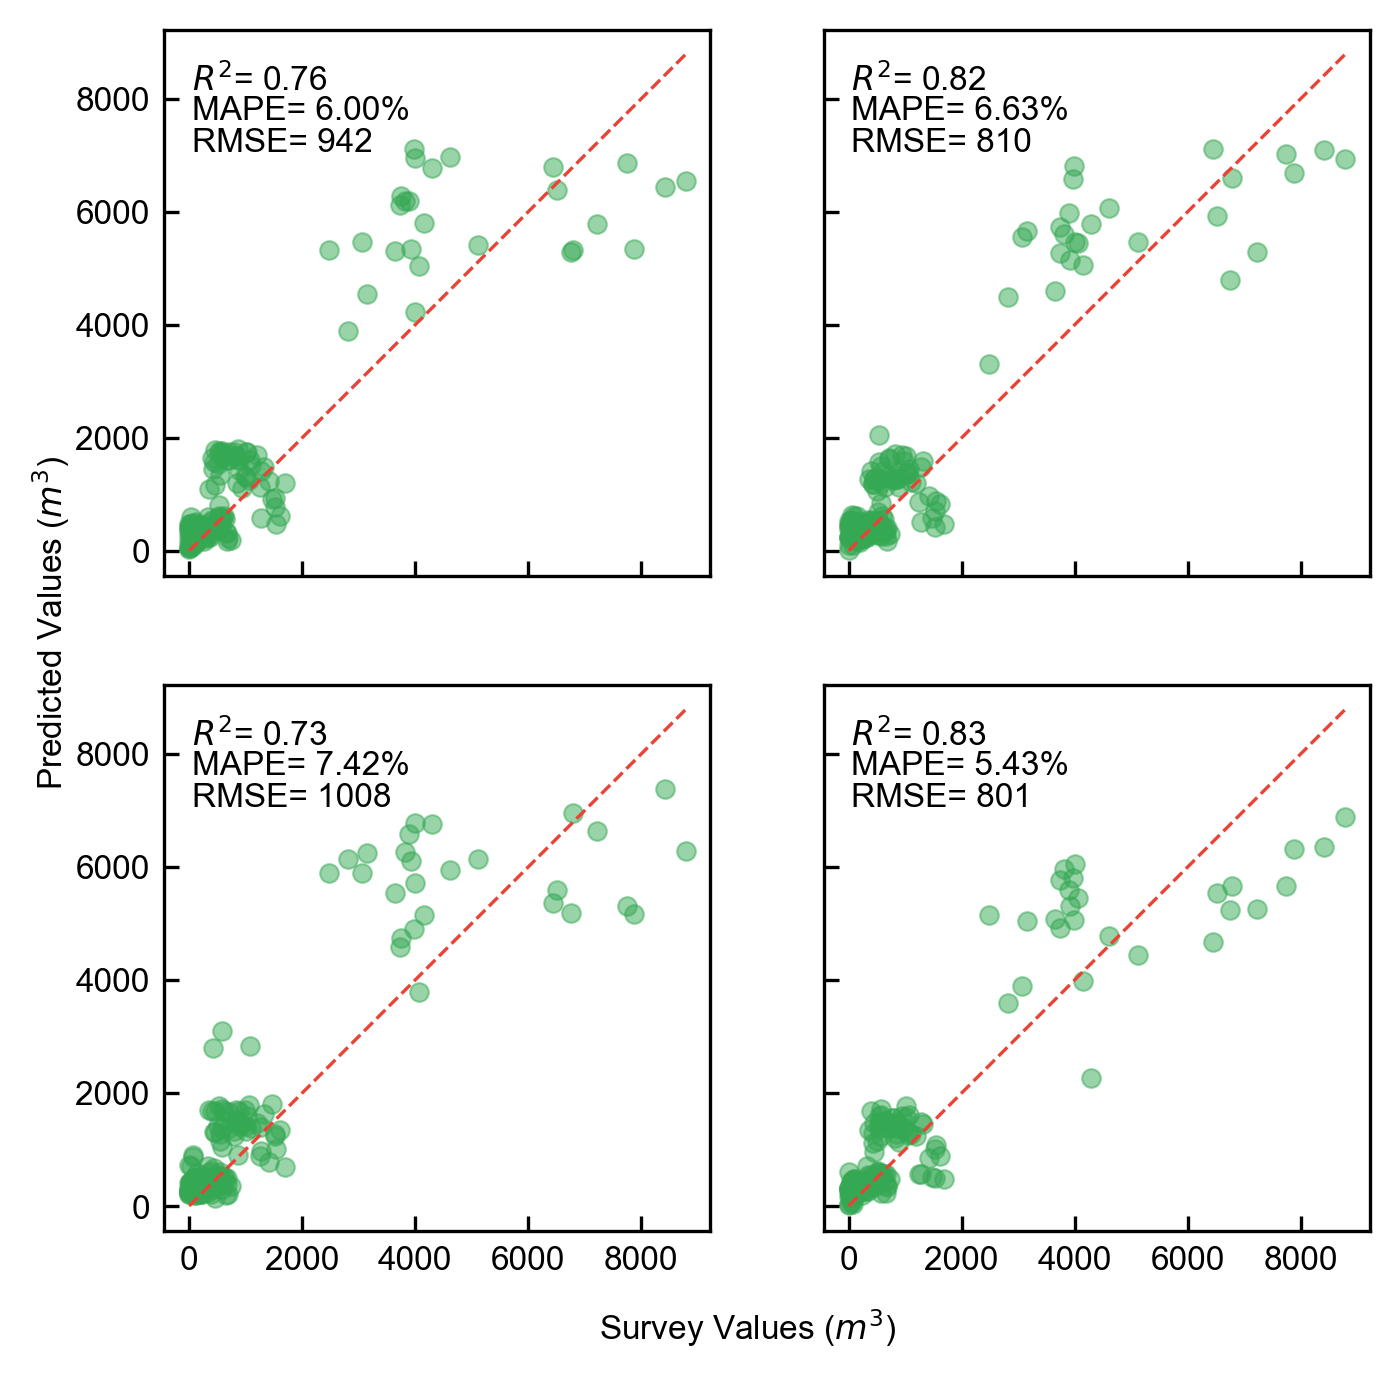

In [12]:
# SCATTER PLOT THE prediction results
# Make predictions on each test set in the list and evaluate
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error


fig, axs = plt.subplots(2, 2, figsize=(5.2, 5.2), sharey=True, sharex=True)

# Loop through each test scenario and predict
for i, X_test in enumerate(list_features_flattened_test):
    print(f"Scenario {i+1}:")

    # Predict using the trained stacking model
    y_pred = stacking_regressor.predict(X_test[:, important_indices])
    print(y_pred)

    # Calculate the R^2 score
    r2 = r2_score(y_test, y_pred)

    # Calculate MAPE (Mean Absolute Percentage Error)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Calculate RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Example visualization of predictions vs actual values for each test set
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test, y_pred, marker='o', s=20, color='#A88EC0', linewidth=0.5, alpha=0.5)

    # Annotate the plot with R², MAPE, and RMSE
    ax.text(0.05, 0.94, f'$R^2$= {r2:.2f}', transform=ax.transAxes, ha='left', va='top')
    ax.text(0.05, 0.88, f'MAPE= {mape:.2f}%', transform=ax.transAxes, ha='left', va='top')
    ax.text(0.05, 0.82, f'RMSE= {rmse:.0f}', transform=ax.transAxes, ha='left', va='top')

    # Plot the 1:1 line for reference
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
    ax.set_aspect('equal', 'box')

# Set common labels
fig.text(0.5, 0.04, 'Survey Values ($m^3$)', ha='center')
fig.text(0.04, 0.5, 'Predicted Values ($m^3$)', va='center', rotation='vertical')

# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_scatter_plot.tiff',dpi=300, bbox_inches='tight')

plt.show()



models = [gscv_mlp, gscv_rf.best_estimator_, gscv_knn.best_estimator_]
colors = ['#EA4335','#FBBC04','#34A853']
# '#EA4335'
for model, color in zip(models, colors):

  fig, axs = plt.subplots(2, 2, figsize=(5.2, 5.2), sharey=True, sharex=True)

  # Loop through each test scenario and predict
  for i, X_test in enumerate(list_features_flattened_test):
      print(f"Scenario {i+1}:")

      # Predict using the trained stacking model
      y_pred_sub = model.predict(X_test[:, important_indices])
      print(y_pred_sub)

      # Calculate the R^2 score
      r2 = r2_score(y_test, y_pred_sub)

      # Calculate MAPE (Mean Absolute Percentage Error)
      mape = mean_absolute_percentage_error(y_test, y_pred_sub)

      # Calculate RMSE (Root Mean Squared Error)
      rmse = np.sqrt(mean_squared_error(y_test, y_pred_sub))

      # Example visualization of predictions vs actual values for each test set
      ax = axs[i // 2, i % 2]
      ax.scatter(y_test, y_pred_sub, marker='o', s=20, color=color, linewidth=0.5, alpha=0.5)

      # Annotate the plot with R², MAPE, and RMSE
      ax.text(0.05, 0.94, f'$R^2$= {r2:.2f}', transform=ax.transAxes, ha='left', va='top')
      ax.text(0.05, 0.88, f'MAPE= {mape:.2f}%', transform=ax.transAxes, ha='left', va='top')
      ax.text(0.05, 0.82, f'RMSE= {rmse:.0f}', transform=ax.transAxes, ha='left', va='top')

      # Plot the 1:1 line for reference
      ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', color='#EA4335', lw=0.8)
      ax.set_aspect('equal', 'box')

  # Set common labels
  fig.text(0.5, 0.04, 'Survey Values ($m^3$)', ha='center')
  fig.text(0.04, 0.5, 'Predicted Values ($m^3$)', va='center', rotation='vertical')

  # plt.savefig(f'/content/drive/MyDrive/NU work/Cotton/Figures/figure_scatter_plot_{model}.tiff',dpi=300, bbox_inches='tight')

  plt.show()





In [13]:
# Refit the model using all available historical data (2000-2023)

import numpy as np
import pandas as pd
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Combine training and validation data for refitting
# Original training data: 2000-2014 (features_flattened_train, water_targets_flattened_train)
# Original validation data: 2015-2023 (features_flattened_test, water_targets_flattened_test)

# Process weather data for complete historical period (2000-2023)
def process_complete_weather_data(weather_historical, total_month):
    """Process complete weather data for the full historical period"""
    weather_data = np.array(weather_historical).reshape(8, 17, total_month).reshape(8, 17, 12, total_month//12).transpose(1, 0, 2, 3).reshape(17, 96, total_month//12)
    new_indices = [9, 15, 16, 8, 5, 10, 13, 4, 0, 11, 6, 1, 2, 14, 12, 7, 3]
    weather_reordered = weather_data[new_indices]
    features_flattened = weather_reordered.transpose(0, 2, 1).reshape(-1, 96)
    return features_flattened

# Combine all historical data (2000-2023)
X_complete = np.vstack([features_flattened_train,
                       features_flattened_test_ssp1])  # Assuming test data represents 2015-2023

y_complete = np.concatenate([water_targets_flattened_train,
                            water_targets_flattened_test])

print(f"Complete dataset shape: X={X_complete.shape}, y={y_complete.shape}")

# Use the same important features identified earlier
X_complete_selected = X_complete[:, important_indices]

# Recreate the ensemble model with same architecture
# Define your best performing models (same as before)
mlp0_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=len(important_indices), epochs=100, batch_size=32, verbose=0))
])

mlp1_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=len(important_indices), epochs=100, batch_size=32, verbose=0))
])

mlp2_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', PositiveKerasRegressor(input_dim=len(important_indices), epochs=100, batch_size=32, verbose=0))
])

# Create the final stacking regressor
meta_model_final = LinearRegression(fit_intercept=True)
base_models_final = [('mlp0', mlp0_final), ('mlp1', mlp1_final), ('mlp2', mlp2_final)]

final_stacking_regressor = StackingRegressor(
    estimators=base_models_final,
    final_estimator=meta_model_final,
    passthrough=False,
    cv=5,
    n_jobs=-1
)

# Fit the model on complete historical data
print("Refitting model on complete historical data (2000-2023)...")
final_stacking_regressor.fit(X_complete_selected, y_complete)

# Now make future predictions (2024-2049) using the refitted model
future_predictions = {}

for i, features_predict in enumerate(list_features_flattened_predict):
    scenario_name = ['SSP1', 'SSP2', 'SSP3', 'SSP5'][i]
    predictions = final_stacking_regressor.predict(features_predict[:, important_indices])
    future_predictions[scenario_name] = predictions
    print(f"{scenario_name} predictions shape: {predictions.shape}")

# Optional: Compare with original model predictions to see the difference
print("\nComparison of prediction differences (refitted vs original):")
for i, scenario in enumerate(['SSP1', 'SSP2', 'SSP3', 'SSP5']):
    original_pred = base_predictions[i]
    refitted_pred = future_predictions[scenario]

    diff = np.mean(np.abs(refitted_pred - original_pred))
    print(f"{scenario}: Mean absolute difference = {diff:.2f}")

# Save the refitted predictions
reshaped_predictions = {}
for scenario, pred in future_predictions.items():
    reshaped_predictions[scenario] = pred.reshape(17, 26)  # 17 states, 26 years

# Combine into single dataframe
combined_refitted_predictions = pd.concat([
    pd.DataFrame(reshaped_predictions['SSP1']),
    pd.DataFrame(reshaped_predictions['SSP2']),
    pd.DataFrame(reshaped_predictions['SSP3']),
    pd.DataFrame(reshaped_predictions['SSP5'])
], axis=1)

# Save refitted predictions
# combined_refitted_predictions.to_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/refitted_predicted_raw_water_consumption.xlsx')

print("Refitted model predictions saved successfully!")

Complete dataset shape: X=(408, 96), y=(408,)
Refitting model on complete historical data (2000-2023)...


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


NameError: name 'list_features_flattened_predict' is not defined

In [ ]:
list_features_flattened_predict = [features_flattened_predict_ssp1,
                                features_flattened_predict_ssp2,
                                features_flattened_predict_ssp3,
                                features_flattened_predict_ssp5]
base_predictions = {}


for i, features_flattened_predict in enumerate(list_features_flattened_predict):
    base_predictions[i] = stacking_regressor.predict(features_flattened_predict[:, important_indices])

print(base_predictions[i])

In [ ]:
# Reshape the array to shape (17, 26)
reshaped_data1 = base_predictions[0].reshape(17, 26)
reshaped_data2 = base_predictions[1].reshape(17, 26)
reshaped_data3 = base_predictions[2].reshape(17, 26)
reshaped_data4 = base_predictions[3].reshape(17, 26)

combined_dataframe_rawprediction = pd.concat([pd.DataFrame(reshaped_data1), pd.DataFrame(reshaped_data2), pd.DataFrame(reshaped_data3), pd.DataFrame(reshaped_data4)], axis=1)
combined_dataframe_rawprediction.to_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_raw_water_consumption.xlsx')
import pandas as pd
import numpy as np

combined_dataframe_rawprediction = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_raw_water_consumption.xlsx', usecols=range(1,105))

print(combined_dataframe_rawprediction)

m, n = 17, 26  # Shape of each original dataset
cols_per_dataset = n

reshaped_data1= combined_dataframe_rawprediction.iloc[:, :cols_per_dataset].values.reshape(m, n)
reshaped_data2 = combined_dataframe_rawprediction.iloc[:, cols_per_dataset:2*cols_per_dataset].values.reshape(m, n)
reshaped_data3 = combined_dataframe_rawprediction.iloc[:, 2*cols_per_dataset:3*cols_per_dataset].values.reshape(m, n)
reshaped_data4 = combined_dataframe_rawprediction.iloc[:, 3*cols_per_dataset:].values.reshape(m, n)




df_water_history = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/water consumption.xlsx', index_col=0)
# print(df_water_history

df_water_history_average = df_water_history.mean(axis=1)

df1 = pd.DataFrame(reshaped_data1-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])
df2 = pd.DataFrame(reshaped_data2-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])
df3 = pd.DataFrame(reshaped_data3-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])
df4 = pd.DataFrame(reshaped_data4-(np.array(df_water_history_average).reshape(17,1)), index=['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA'])


# List to store interleaved rows
interleaved_rows = []

# Iterate through the rows using zip
for i in range(len(df1)):
    interleaved_rows.append(df1.iloc[i])
    interleaved_rows.append(df2.iloc[i])
    interleaved_rows.append(df3.iloc[i])
    interleaved_rows.append(df4.iloc[i])


# List of states
state = ['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA']

# List of scenarios
sce = ['', 'SSP2', 'SSP3', 'SSP5']

# Generate index names
new_index = [f'{st}{sc}' for st in state for sc in sce]

# Combine the list into a final DataFrame
df_combined = pd.DataFrame(interleaved_rows).reset_index(drop=True)
df_combined.index = new_index
# df_combined.to_excel('/content/drive/MyDrive/NU work/Cotton/Python outputs/predicted_water_consumption.xlsx')

# Calculate row and column sums
row_sums = df_combined.sum(axis=1)  # Sum horizontally
col_sums = df_combined.sum(axis=0)  # Sum vertically


#### plot
fig = plt.figure(figsize=(7.2, 6))
divider = fig.add_gridspec(2, 2,  width_ratios=(4, 1),height_ratios=(1, 5),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.05)

main_ax = fig.add_subplot(divider[1,0])
# Iterate through the DataFrame to plot each bubble
for index, row in df_combined.iterrows():
    for col in df_combined.columns:
        value = row[col]
        # Choose color based on whether the value is positive or negative
        color = '#A88EC0' if value > 0 else '#A4D5B1'
        # Plot the bubble
        main_ax.scatter(col, index, s=abs(value) / 20, color=color, alpha=0.5)


colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']
# Row sums (plotted to the right of the main plot)
row_sum_ax = fig.add_subplot(divider[1, 1], sharey=main_ax)
row_sum_ax.barh(df_combined.index,row_sums/(26), color=colors, alpha=0.5)
row_sum_ax.set_xlabel('Horizontal Average \n($m^3$/1000kg cotton lint)',fontsize=6 )
# row_sum_ax.set_xticklabels(['','2024', '2029', '2034', '2039', '2044', '2049'], fontsize=6)
# row_sum_ax.invert_xaxis()
# row_sum_ax.invert_yaxis()
# row_sum_ax.set_xlim(0, row_sums.max() * 1.1)  # Adjust limits

# Column sums (plotted above the main plot)
col_sum_ax = fig.add_subplot(divider[0,0], sharex=main_ax)
# Determine the color for each bar: red for positive, blue for negative
bar_colors = ['#A88EC0' if value > 0 else '#A4D5B1' for value in col_sums]

col_sum_ax.bar(df_combined.columns, col_sums/(17*4),  color=bar_colors, alpha=0.5)
# col_sum_ax.set_ylim(0, col_sums.max() * 1.1)  # Adjust limits
col_sum_ax.set_ylabel('Vertical Average\n($m^3$/1000kg cotton lint)', fontsize=6)
col_sum_ax.set_xticklabels(['','2024', '2029', '2034', '2039', '2044', '2049'], fontsize=6)

yticks = range(0, len(df_combined), 4)
main_ax.set_yticks(yticks)
main_ax.set_yticklabels(df_combined.index[yticks])

main_ax.set_xticklabels(['','2024', '2029', '2034', '2039', '2044', '2049'], fontsize=8)
main_ax.set_ylabel('States')
# row_sum_ax.set_yticklabels([])
# # Add labels and title
# ax.set_xlabel('Columns')
# ax.set_ylabel('States')
# ax.set_title('Bubble Chart of Reshaped Data')

# Show grid for better readability
main_ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_predictedbubble.tiff',dpi=300, bbox_inches='tight')
# Display the plot
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
water_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/processed_data and results/Water_Percent.xlsx')
sampling_water_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/processed_data and results/sampling_for_production_percentage.xlsx', usecols=lambda column: column not in ['Unnamed: 0'])

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

'''
# Data
previous_data = {
    "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
             2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Value": [2201.239861, 1879.560670, 1887.966901, 1763.507703, 1458.329535, 1381.608790,
              1504.554985, 1281.436246, 1592.075369, 1596.170563, 1351.764412, 2183.237067,
              1665.212840, 1414.058403, 1188.301581, 1150.028463, 1112.019481, 1207.388310,
              1405.617009, 1249.544738, 1463.268468, 1086.639767, 1526.283632, 1330.403125]
}

# Create DataFrame
df_previous = pd.DataFrame(previous_data)

# Set 'Year' as the index
df_previous.set_index('Year', inplace=True)



years = np.arange(2024, 2050)  # Example years from 1995 to 2020


# Create a 2x1 subplot
fig, axs = plt.subplots(4, 1, figsize=(7.2, 5),
                        sharey=True,
                        sharex=True)

# fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Colors for different predictions
colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853']
colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']

line_styles = ['-', '--', '-.', ':']

future_average=[]
# First subplot: first two base_predictions
for i, (key, base_pred) in enumerate(list(base_predictions.items())):
    # Reshape the base predictions
    reshaped_data = base_pred.reshape(17, 26)

    # Perform the dot product
    results = np.dot(sampling_water_percent, reshaped_data)

    # Create DataFrame
    df = pd.DataFrame(results.T, index=years)

    # Calculate the statistics
    average_values = df.mean(axis=1)
    min_values = df.min(axis=1)
    max_values = df.max(axis=1)

    future_average.append(average_values)
    future_average.append(min_values)
    future_average.append(max_values)
    # Plotting
    axs[i].plot(df_previous.index, df_previous['Value'], color='#202124', linewidth=0.5)
    axs[i].plot(df.index, average_values, label=f'Average {key}', color=colors[i], linestyle='--', linewidth=0.5)
    axs[i].fill_between(df.index, min_values, max_values, color=colors[i], alpha=0.1, label=f'Min/Max Range {key}', edgecolor='none')
    axs[i].axvspan(2023, 2024, facecolor='#9AA0A6', alpha=0.3, edgecolor='none')

'''









import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Sample data as given by user
# previous_data = {
#     "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
#              2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
#     "Value": [
#     2281.494098,
#     1948.086917,
#     1956.799627,
#     1827.802816,
#     1511.498263,
#     1431.980383,
#     1559.409030,
#     1328.155683,
#     1650.120290,
#     1654.364789,
#     1401.047920,
#     2262.834946,
#     1725.924254,
#     1465.613065,
#     1231.625454,
#     1191.956950,
#     1152.562212,
#     1251.408059,
#     1456.863909,
#     1295.101454,
#     1516.617263,
#     1126.257188,
#     1581.929875,
#     1378.907828
# ]}
previous_data = {
    "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
             2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Value": [1853.181355, 1596.030937, 1634.189531, 1510.225051, 1367.249686, 1327.999080,
              1300.773812, 1297.340748, 1414.761542, 1433.794234, 1398.765468, 1585.035214,
              1358.692156, 1090.963036, 1042.019891, 1139.378042, 1092.362063, 1118.108695,
              1097.238793, 1096.024428, 1068.022877, 994.640806, 897.099206, 967.590952]
}


# Create DataFrame
df_previous = pd.DataFrame(previous_data)

# Set 'Year' as the index
df_previous.set_index('Year', inplace=True)


years = np.arange(2024, 2050)  # Example years from 2024 to 2050


# Colors for different predictions
colors = ['#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']

# colors = ['#9AA0A6', '#FAD2CF', '#FEEFC3', '#4285F4']
# Create a 3D plot
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')

all_average_values=[]
all_min_values=[]
all_max_values=[]
all_average_values.append(np.array(df_previous['Value']))
# Iterate over the base_predictions and plot them

base_predictions ={
    'SSP1': reshaped_data1,
    'SSP2': reshaped_data2,
    'SSP3': reshaped_data3,
    'SSP5': reshaped_data4
}

for i, (key, base_pred) in enumerate(base_predictions.items()):
    # Reshape the base predictions
    reshaped_data = base_pred.reshape(17, 26)

    # Perform the dot product
    results = np.dot(sampling_water_percent, reshaped_data)

    # Create DataFrame
    df = pd.DataFrame(results.T, index=years)

    # Calculate the statistics
    average_values = df.mean(axis=1)
    min_values = df.min(axis=1)
    max_values = df.max(axis=1)
    all_average_values.append(average_values)
    all_min_values.append(min_values)
    all_max_values.append(max_values)
    # print(average_values)
    # Plotting
    ax.bar(df_previous.index, df_previous['Value'],[1.5]*len(df_previous.index), zdir='y',color='#E37400', alpha=0.2)
    ax.plot(df.index, [i]*len(df.index), average_values, label=f'Average {key}', color=colors[i], linestyle='-', linewidth=0.6)
    # ax.plot(df.index, [i]*len(df.index), min_values, color=colors[i], alpha=0.5)
    # ax.fill_between(df.index, min_values, max_values, color=colors[i], alpha=0.1, label=f'Min/Max Range {key}', edgecolor='none')
    for j in range(len(df.index)-1):
        verts = [
            [df.index[j], i, min_values.iloc[j]],
            [df.index[j], i, max_values.iloc[j]],
            [df.index[j+1], i, max_values.iloc[j+1]],
            [df.index[j+1], i, min_values.iloc[j+1]],
        ]
        poly = Poly3DCollection([verts], color=colors[i], alpha=0.6, edgecolor='none')
        ax.add_collection3d(poly)
    # ax.plot(df.index, [i]*len(df.index), max_values, color=colors[i], alpha=0.5)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# ax.set_xlabel('Year')
# ax.set_ylabel('Prediction Index')
# ax.set_zlabel('Value')
# ax.legend()

ax.view_init(elev=55, azim=-75)

yticks = [0, 1, 2, 3]
ax.set_yticks(yticks)
ax.set_yticklabels(['SSP1','SSP2','SSP3','SSP5'])

ax.grid(True)
ax.xaxis._axinfo['grid'].update(color = 'gray', linestyle = '-', linewidth = 0.05)
ax.yaxis._axinfo['grid'].update(color = 'gray', linestyle = '-', linewidth = 0.05)
ax.zaxis._axinfo['grid'].update(color = 'gray', linestyle = '-', linewidth = 0.05)

# ax.set_rasterized(True)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig2_3dpoly.eps',format='eps', dpi=600)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_uncertaintyplot.tiff',dpi=300, bbox_inches='tight')
plt.show()



##############################
#box plots
import seaborn as sns
average_values_df = pd.DataFrame(all_average_values).T
# colors = ['#E37400','#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']
# # Create the boxplot
# plt.figure(figsize=(10, 6))
# order = ['A', 'B', 'C', 'D', 'E']

# sns.boxplot(data=average_values_df, order=order, palette=colors, positions=[0, 2, 5, 8, 11])


# sns.boxplot(data=all_min_values, palette=colors, positions=[1, 4, 7, 10])
# sns.boxplot(data=all_max_values, palette=colors, positions=[3,6,9,12])

# plt.axvspan(-0.5, 0.5, facecolor='#9AA0A6', alpha=0.2, edgecolor='none')
# plt.title('Boxplot of Average Values for Each Model')
# plt.ylabel('Average Value')
# plt.xlabel('Model')
# plt.show()

fig, ax = plt.subplots(figsize=(3, 1.5))

print(average_values_df)
flierprops = dict(marker='o', color='k', markersize=2,markeredgewidth=0.5)
boxprops = dict(color='white', linewidth=0.1)
meanprops = {
    'linestyle': '-',  # Dashed line
    'color': 'grey',    # Blue color
    'linewidth': 1      # Line width
}

bplot1 =ax.boxplot(np.array(df_previous['Value']), patch_artist=True, positions=[-1], showmeans=True, meanline=True,  widths=0.5, whis=3,  flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)
bplot2 =ax.boxplot(average_values_df, positions=[0, 2, 6, 10, 14], patch_artist=True ,showmeans=True, meanline=True,  widths=0.5, whis=3,flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)  # will be used to label x-ticks

bplot3 =ax.boxplot(all_min_values, positions=[1, 5, 9, 13],patch_artist=True, showmeans=True, meanline=True, widths=0.5, whis=3,flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)
bplot4 =ax.boxplot(all_max_values, positions=[3,7,11,15], patch_artist=True, showmeans=True, meanline=True, widths=0.5, whis=3,flierprops=flierprops, boxprops=boxprops, meanprops=meanprops)
ax.axvspan(-2, 0, facecolor='#E37400', alpha=0.1, edgecolor='none')


colors = ['#E37400','#9AA0A6', '#EA4335', '#FBBC04', '#4285F4']
# fill with colors
for patch in bplot1['boxes']:
    patch.set_facecolor(colors[0])
    patch.set_alpha(0.6)

# For average_values_df boxplot
for patch, color in zip(bplot2['boxes'], colors[:len(bplot2['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# For all_min_values boxplot
for patch, color in zip(bplot3['boxes'], colors[1:(len(bplot3['boxes'])+1)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# For all_max_values boxplot
for patch, color in zip(bplot4['boxes'], colors[1:(len(bplot4['boxes'])+1)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

xticks = [-1, 2, 6, 10, 14]
ax.set_xticks(xticks)
ax.set_xticklabels(['Historical','SSP1','SSP2','SSP3','SSP5'])
plt.ylabel('Irrigation Water\n($m^3$/1000 kg cotton lint)', fontsize=6)
ax.set_rasterized(True)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/manuscript fig/fig2_box.eps',format='eps', dpi=600)
# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/figure_boxplot.tiff',dpi=300, bbox_inches='tight')
plt.show()




# Display the plot

# axs[1].set_ylabel('Water consumption (m$^3$/1000kg)')
# axs[3].set_xlabel('Year')

# plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/fig_future_range.tiff',dpi=300, bbox_inches='tight')
# plt.show()


# average_values_df.to_excel('/content/drive/MyDrive/NU work/Cotton/Water_future_average.xlsx')

In [ ]:
print(average_values_df)

In [ ]:
import numpy as np

'''
data_production_percent = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/Production_Percent.xlsx', usecols=range(1,18))

print(data_production_percent)
# Example arrays of min and max values
min_values = data_production_percent.min()
print(min_values)
# np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20, 0.21])
max_values = data_production_percent.max()
# np.array([0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26])

# Define data_ranges by zipping the min and max arrays
data_ranges = list(zip(min_values, max_values))


# Number of samples
n_samples = 1000

# Initialize an array to hold the normalized samples
valid_samples = []

# Rejection sampling function
def sample_within_ranges(data_ranges):
    while True:
        samples = np.array([np.random.uniform(low, high) for low, high in data_ranges])
        if np.isclose(samples.sum(), 1, atol=1e-4):  # Check if the sum is close to 1
            return samples

# Generate valid samples
for _ in range(n_samples):
    valid_samples.append(sample_within_ranges(data_ranges))

# Convert the list of valid samples to a NumPy array
valid_samples_array = np.array(valid_samples)
print(valid_samples_array)
'''
# pd.DataFrame(valid_samples_array).to_excel('/content/drive/MyDrive/NU work/Cotton/sampling_for_production_percentage.xlsx')